# Unsupervised Clustering for Plant Health
### AI for Plant Pathologists

In **unsupervised** learning you have **no labels** — you ask the data
to reveal its own structure. **Clustering** is the flagship unsupervised task:
*group samples so that things in the same group are similar, and different groups are dissimilar.*

**Why this matters for plant pathology and plant-health studies:**
- Group unlabeled leaf/lesion images or field samples into natural disease types **before**
  anyone hand-labels thousands of them.
- Discover sub-populations (pathotypes/races) of a pathogen from morphological or genomic features.
- **Flag outliers** — a sample that fits no cluster may be a new strain, a novel disease, or a
  measurement error worth re-checking.
- Reduce many field/lab measurements into a picture you can actually interpret.

### The algorithms that matter most
1. **K-Means** — the workhorse; fast, simple, assumes round groups.
2. **Choosing the number of clusters** — elbow method + silhouette score.
3. **Hierarchical (Agglomerative) clustering** — builds a tree (dendrogram), like a phylogeny.
4. **DBSCAN** — density-based; finds odd shapes and labels noise/outliers.
5. **PCA** — compress many measurements to 2-D so clusters can be seen.
7. **A full case study** — cluster a *Clavibacter* strain-phenotyping panel and validate it.

> Run every cell in order (**Shift+Enter**). Change numbers, re-run, break things — that's how
> you learn. Solutions to the exercises are at the bottom.

---

## 0 · Setup — import the tools

Everything here ships with Colab. `scikit-learn` (imported as `sklearn`) is the standard
machine-learning library in Python and contains every clustering algorithm we need.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

np.random.seed(42)          # makes results reproducible
print("Libraries loaded.")

Libraries loaded.


## 1 · Our running example — *Clavibacter nebraskensis* strain virulence

**The system.** *Clavibacter nebraskensis* is a Gram-positive bacterium that causes **Goss's
wilt** in corn. To compare how aggressive different bacterial **strains** are, we run a
**clip-inoculation assay**: each corn leaf tip is cut with scissors dipped in a strain's
suspension, and the resulting disease is then measured.

**The data.** We inoculated **300 corn leaves** with a panel of strains and, for each leaf,
recorded two very different readouts:

- **Lesion length (mm)** — the visible symptom spreading from the clipped tip (longer = more aggressive).
- **Fv/Fm** — maximum quantum yield of Photosystem II from a **chlorophyll-fluorescence** meter; a
  physiological measure of photosynthetic health (~0.80 in healthy corn, falling as infection damages it).

The leaves arrived **unlabeled** — we don't yet know how many distinct **virulence groups** the
strains fall into. Clustering can reveal them. (We use just two readouts here so we can *see* what
each algorithm does; §9 brings in more instruments.)


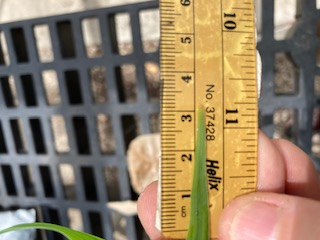

In [11]:
#This code will "build synthetic data using a couple of comand lines"
# Lets build 300 inoculated leaves from 4 (hidden) virulence groups. y_true = class, which we pretend not to see.
rng = np.random.default_rng(42) # this comand generate number strating from 42 as seed. Why? to be sure that we cna replicate results
n = 75    # leaves per virulence group - each group will have 75 points

# each group = (mean lesion mm, mean Fv/Fm, lesion sd, Fv/Fm sd);  more virulent -> longer lesion, lower Fv/Fm
specs = [( 10, 0.80, 4, 0.020),
         ( 60, 0.71, 6, 0.025),
         (110, 0.61, 6, 0.025),
         (175, 0.50, 7, 0.030)]

blocks, y_true = [], []                          # empty lists: one for the data chunks, one for the group labels
for grp, (lesion, fvfm, sl, sf) in enumerate(specs):   # loop over each group; grp = index (0,1,2...), unpack its 4 settings
    blocks.append(np.column_stack([              # build one group's data and add it to the list
        rng.normal(lesion, sl, n),               #   n random lesion lengths, centered at 'lesion', spread 'sl'
        rng.normal(fvfm, sf, n)                   #   n random Fv/Fm values, centered at 'fvfm', spread 'sf'
    ]))                                          #   column_stack pairs them into an (n, 2) block: 1 row = 1 leaf
    y_true += [grp] * n                          # tag all n leaves in this group with the group number

X = np.vstack(blocks)                            # stack every group's block into one big table (all leaves together)
X[:, 0] = X[:, 0].clip(0)                        # column 0 = lesion length: force any negative values up to 0
X[:, 1] = X[:, 1].clip(0, 0.85)                  # column 1 = Fv/Fm: keep between 0 and 0.85 (real plants max out ~0.83)
y_true = np.array(y_true)                        # turn the list of labels into a NumPy array

leaves = pd.DataFrame(X, columns=["lesion_length_mm", "fv_fm"])  # wrap the array in a table with named columns
print("Shape:", X.shape, " -> 300 inoculated leaves, 2 readouts each")  # report size: 300 rows, 2 measurements each
leaves.round(2).head()                           # show the first 5 rows, rounded to 2 decimals, to preview the data

Shape: (300, 2)  -> 300 inoculated leaves, 2 readouts each


,lesion_length_mm,fv_fm
0,11.22,0.81
1,5.84,0.79
2,13.00,0.80
3,13.76,0.81
4,2.20,0.79


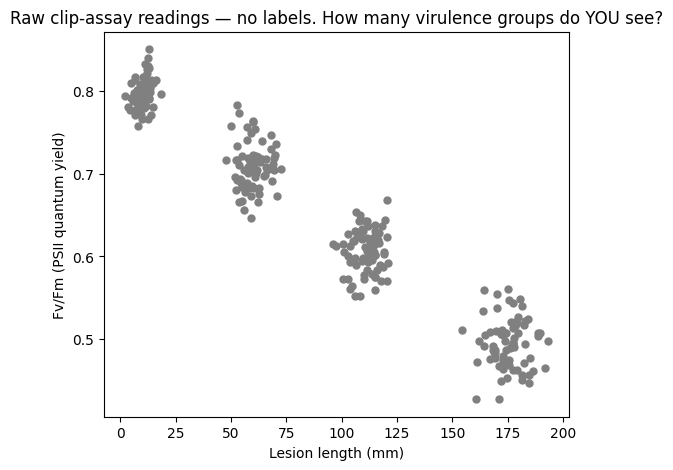

In [12]:
plt.figure(figsize=(6, 5))                       # start a new figure, 6 inches wide by 5 tall
plt.scatter(X[:, 0], X[:, 1], s=25, color="gray")  # scatter plot: x = lesion length (col 0), y = Fv/Fm (col 1), dots size 25, all gray
plt.title("Raw clip-assay readings — no labels. How many virulence groups do YOU see?")  # title posing the question to students
plt.xlabel("Lesion length (mm)")                 # label the x-axis with its measurement and units
plt.ylabel("Fv/Fm (PSII quantum yield)")         # label the y-axis with its measurement
plt.show()                                       # render and display the figure

Your eye probably sees ~4 clumps. A clustering algorithm makes that judgment mathematically —
and, crucially, keeps working in 10 or 100 dimensions where you simply **cannot** look.

## 2 · First, always scale your features. IMPORTANT!!

Clustering is based on **distance** between samples, and our two readouts live on **totally
different scales**: **lesion length** runs 0–~200 mm, but **Fv/Fm** runs only 0–1. Left as-is,
lesion length (big numbers) would dominate every distance and Fv/Fm would be almost ignored.
**Standardizing** puts every feature on equal footing: mean 0, standard deviation 1.

Rule of thumb: **scale before clustering** unless your features are already comparable.
`StandardScaler` does it in two lines.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # subtract mean, divide by std, per column

print("Before scaling — means:", X.mean(axis=0).round(2), " stds:", X.std(axis=0).round(2))
print("After  scaling — means:", X_scaled.mean(axis=0).round(2), " stds:", X_scaled.std(axis=0).round(2))

# We will use X_scaled from now on as good practice.

Before scaling — means: [89.1   0.65]  stds: [61.54  0.12]
After  scaling — means: [-0. -0.]  stds: [1. 1.]


## 3 · K-Means — the workhorse

**Idea (plain words):** you tell K-Means how many clusters you want, *k*. It then:
1. Drops *k* points ("centroids") at random.
2. Assigns every leaf to its **nearest** centroid.
3. Moves each centroid to the **average** of its assigned leaves.
4. Repeats 2–3 until the centroids stop moving.

| | |
|---|---|
| **✅ Advantages** | Very fast and scales to large datasets; simple to explain; works well when groups are roughly round and similar-sized. |
| **⚠️ Limitations** | You must choose *k* in advance; assumes round, equal-sized clusters (fails on elongated/curved shapes); forces every sample into a cluster (no outlier concept); sensitive to feature scaling and to the random start. |
| **🎯 Best applied when** | A quick first pass on a new plant-health dataset — e.g. sorting hundreds of isolates or leaves into a handful of morphologically compact groups, or as the baseline before trying anything fancier. |

Let's group the leaves into `k = 4` virulence groups.

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)  # set up k-means to find 4 clusters; random_state fixes the result so it's reproducible; n_init=10 tries 10 starts and keeps the best
labels_km = kmeans.fit_predict(X_scaled)   # run k-means on the scaled data and return each leaf's cluster (0,1,2,3)

print("First 20 cluster labels:", labels_km[:20])   # peek at the cluster assigned to the first 20 leaves
print("Leaves per cluster:", np.bincount(labels_km))  # count how many leaves landed in each cluster (index = cluster number)

First 20 cluster labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Leaves per cluster: [75 75 75 75]


**What is k-means doing?** It sorts our leaves into groups based only on their measurements. It never sees the real answer key (y_true) — it tries to discover the groups on its own. (This is called unsupervised learning.)

**We chose the number of groups.** n_clusters=4 tells k-means "find exactly 4 groups." K-means doesn't figure out the number for us — we picked it. Think about: how did we decide on 4?

**Why random_state=42? **It makes the result the same every time you run it, so your screen matches everyone else's.

**Why n_init=10?** K-means can get a bad answer depending on where it randomly starts. Running it 10 times and keeping the best result avoids that.

The cluster numbers don't mean anything. K-means labels its groups 0, 1, 2, 3 — but its "cluster 2" is not necessarily the same as our REAL "group 2." It finds the groupings but numbers them however it likes.

**Why scaled data?** Lesion length (0–50 mm) and Fv/Fm (0–0.83) are on very different scales. K-means measures distance, so without scaling, lesion length would take over completely. Scaling gives both measurements an equal say.

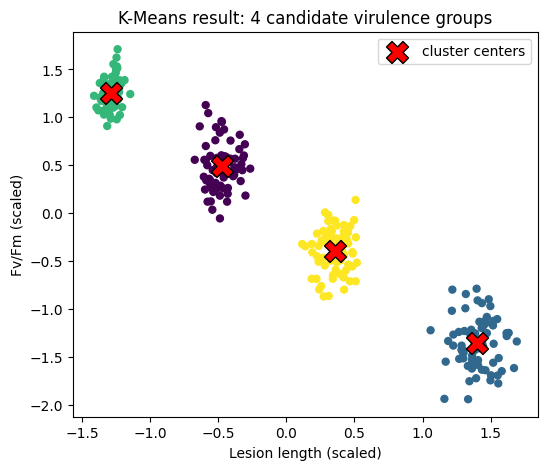

In [16]:
centroids = kmeans.cluster_centers_              # grab the center point of each cluster (the "average leaf" of each group)

plt.figure(figsize=(6, 5))                       # start a new figure, 6 inches wide by 5 tall
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_km, cmap="viridis", s=25)  # plot every leaf; color (c=) each dot by its cluster, using the viridis color scheme, dot size 25
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=250,       # plot the cluster centers as big red X's on top
            edgecolor="black", label="cluster centers")                          # black outline so they stand out; label for the legend
plt.title("K-Means result: 4 candidate virulence groups")  # title describing what the plot shows
plt.xlabel("Lesion length (scaled)"); plt.ylabel("Fv/Fm (scaled)")  # label both axes (note: scaled values, not raw mm)
plt.legend(); plt.show()                          # show the legend (for the red X's), then render the figure

Each color is a virulence group the algorithm discovered on its own; the red X's are the cluster
centers (the "average" leaf of each group). The label numbers 0–3 are arbitrary names —
cluster "2" is not more severe than cluster "0"; they're just tags.

### WHY SCALING IS IMPORTANT !!! LETS DO AN EXAMPLE!! See it for yourself — scaling changes the *result*, not the picture

Here's the subtle part: **the scatter looks the same before and after scaling** (matplotlib just
re-labels the axes), so scaling seems to do nothing. But clustering never looks at the picture —
it looks at **distances**, and scaling changes those. Watch it flip a K-Means result.

Mini-example: two virulence groups, each leaf measured two ways —
- **`bacterial_load`** (bacteria recovered, CFU): **huge** numbers that happen to **overlap** between
  the two groups (so, not informative here).
- **`fv_fm`**: **small** numbers (0–1) that **cleanly separate** the two groups.

In [ ]:
rng = np.random.default_rng(1); n = 100          # fresh random generator (seed 1 for reproducibility); 100 leaves per group
bacterial_load = rng.normal(100000, 40000, 2*n).clip(0)  # 200 bacterial-load values, huge numbers (~100,000) with BIG overlap between groups; clip stops negatives
fvfm = np.concatenate([rng.normal(0.80, 0.02, n),        # first 100 leaves: healthy Fv/Fm around 0.80
                       rng.normal(0.55, 0.02, n)]).clip(0, 0.85)  # next 100: sick Fv/Fm around 0.55 — these two clearly SEPARATE; clip to valid range
demo = np.column_stack([bacterial_load, fvfm])   # combine into (200, 2): col 0 = bacterial load, col 1 = Fv/Fm
demo_true = np.array([0]*n + [1]*n)              # the real answer key: first 100 are group 0, next 100 are group 1

raw_labels    = KMeans(2, n_init=10, random_state=0).fit_predict(demo)   # run k-means on RAW data (no scaling)
scaled_labels = KMeans(2, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(demo))  # run k-means on SCALED data (both columns standardized first)

print("ARI WITHOUT scaling:", round(adjusted_rand_score(demo_true, raw_labels), 3), " (0 = random -> wrong)")   # score how well the no-scaling clusters match the truth
print("ARI WITH    scaling:", round(adjusted_rand_score(demo_true, scaled_labels), 3), " (1 = perfect)")        # score how well the scaled clusters match the truth

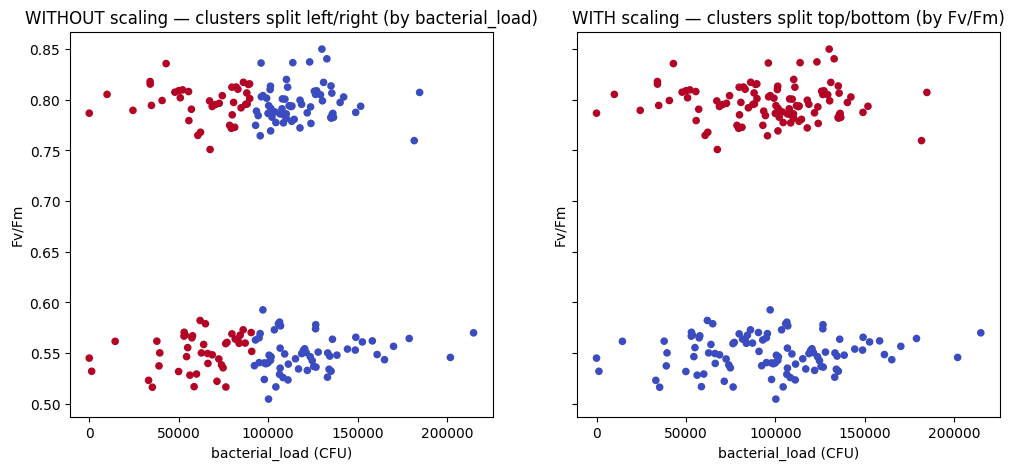

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)  # make 2 side-by-side plots (1 row, 2 cols); sharey means both share the same y-axis for fair comparison
ax[0].scatter(demo[:,0], demo[:,1], c=raw_labels, cmap="coolwarm", s=20)  # LEFT plot: raw data, colored by the NO-scaling clusters
ax[0].set_title("WITHOUT scaling — clusters split left/right (by bacterial_load)")  # title: notice the split runs left/right
ax[1].scatter(demo[:,0], demo[:,1], c=scaled_labels, cmap="coolwarm", s=20)  # RIGHT plot: same points, colored by the WITH-scaling clusters
ax[1].set_title("WITH scaling — clusters split top/bottom (by Fv/Fm)")  # title: notice the split now runs top/bottom
for a in ax: a.set_xlabel("bacterial_load (CFU)"); a.set_ylabel("Fv/Fm")  # label the x and y axes on both plots
plt.show()                                        # render both plots together

**Same points in both panels — only the coloring (the clusters K-Means found) differs.** Without
scaling, the giant `bacterial_load` numbers dominate every distance, so K-Means slices the cloud
**left/right** by bacterial load and **ignores Fv/Fm entirely** — the true groups (top vs bottom) get
scrambled (ARI ≈ 0). After scaling, both features count equally and K-Means recovers the real
groups (ARI = 1). *That* is why we scale — even though the raw scatter looked perfectly fine.

Back to our clip-assay data: from here on we cluster **`X_scaled`**.

**In case later you can get the real groups**
The Adjusted Rand Index (ARI) is a metric used to evaluate the quality of a clustering model by measuring how similar its cluster assignments are to a set of true benchmark labels.

1.0: Perfect agreement between the clustering model and the true labels.

0.0: The clustering is purely random (no better than flipping a coin).

Negative: The clustering is worse than random, meaning the assignments are actively conflicting with the true structure.

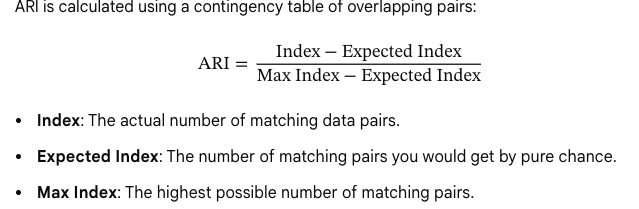

## 4 · How many virulence groups? Choosing *k*

Real data doesn't announce *k*. Two standard tools:

**(a) Elbow method.** For each *k*, K-Means reports **inertia** = total squared distance from
leaves to their centroid (lower = tighter clusters). Inertia always drops as *k* rises, but
the *improvement* flattens. The "elbow" — where extra clusters stop helping — is a good *k*.

**(b) Silhouette score.** Ranges −1 to +1; how well each leaf fits its own cluster vs the
nearest other cluster. **Higher is better.** Pick the *k* with the top score.

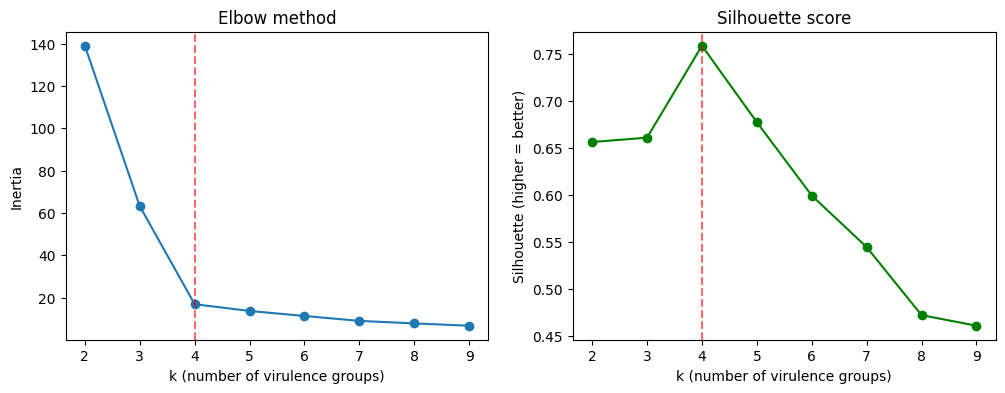

Best k by silhouette: 4


In [ ]:
ks = range(2, 10)                                # the candidate numbers of clusters to try: 2,3,4,...,9
inertias, silhouettes = [], []                   # empty lists to collect one score of each type per k

for k in ks:                                     # loop: try k-means with each number of clusters
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)  # run k-means for this k on the scaled data
    inertias.append(km.inertia_)                 # store inertia: how tightly packed the clusters are (lower = tighter)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))  # store silhouette: how well-separated the clusters are (higher = better)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))    # make 2 side-by-side plots: elbow on left, silhouette on right
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Elbow method")  # LEFT: plot inertia vs k as a line with dots
ax[0].set_xlabel("k (number of virulence groups)"); ax[0].set_ylabel("Inertia")  # label the left plot's axes
ax[0].axvline(4, color="red", ls="--", alpha=0.6)  # draw a dashed red line at k=4 to mark the "elbow"

ax[1].plot(list(ks), silhouettes, "o-", color="green"); ax[1].set_title("Silhouette score")  # RIGHT: plot silhouette vs k in green
ax[1].set_xlabel("k (number of virulence groups)"); ax[1].set_ylabel("Silhouette (higher = better)")  # label the right plot's axes
best_k = list(ks)[int(np.argmax(silhouettes))]   # find the k with the HIGHEST silhouette score (argmax = position of the max)
ax[1].axvline(best_k, color="red", ls="--", alpha=0.6)  # draw a dashed red line at that best k
plt.show()                                       # render both plots

print("Best k by silhouette:", best_k)           # print the winning number of clusters

Choosing k: the two plots

We don't have to guess the number of clusters — we try every k from 2 to 9 and score each one two ways.

**Elbow method (left plot).** The y-axis is inertia — how tightly points hug their cluster centers (lower = tighter). Inertia always drops as k goes up, so you don't pick the lowest. You look for the elbow: the bend where the line stops dropping steeply and flattens out. That bend is the sweet spot.

**Silhouette score (right plot)**. The y-axis is the silhouette — how well-separated the clusters are (about −1 to 1, higher = better). Here you just pick the peak. argmax finds it automatically.

**Quick contrast** the elbow needs judgment (you eyeball the bend), while the silhouette gives a clear winner (the highest point). Using both is good practice — if they agree, you're more confident.

**Caveat** these methods suggest a number, they don't hand you absolute truth. On messy real data the elbow can be blurry and the silhouette peak may sit at a k that doesn't match the biology — so combine them with what you know about the subject.

## 5 · Hierarchical clustering

**Idea:** start with every leaf as its own cluster, then repeatedly **merge the two closest
clusters** until all are joined. The merge history is a tree — a **dendrogram** — and you choose
the number of clusters *afterwards* by "cutting" it.

**Why plant scientists like this:** a dendrogram reads exactly like the **phylogenetic /
relatedness trees** you already use — leaves that join low are very similar; a tall branch
means a big morphological jump.

| | |
|---|---|
| **✅ Advantages** | No need to fix *k* beforehand — the dendrogram shows structure at every level; output is an intuitive tree, familiar to anyone who reads phylogenies; deterministic (no random start). |
| **⚠️ Limitations** | Slow and memory-heavy on large datasets (thousands+ of samples); merges are final — an early mistake can't be undone; the chosen linkage method (ward/average/…) changes the result. |
| **🎯 Best applied when** | Small-to-medium sample sets where relationships matter — e.g. relating a few dozen isolates or accessions, or exploring how pathotypes nest within one another, and you want a tree to show colleagues. |

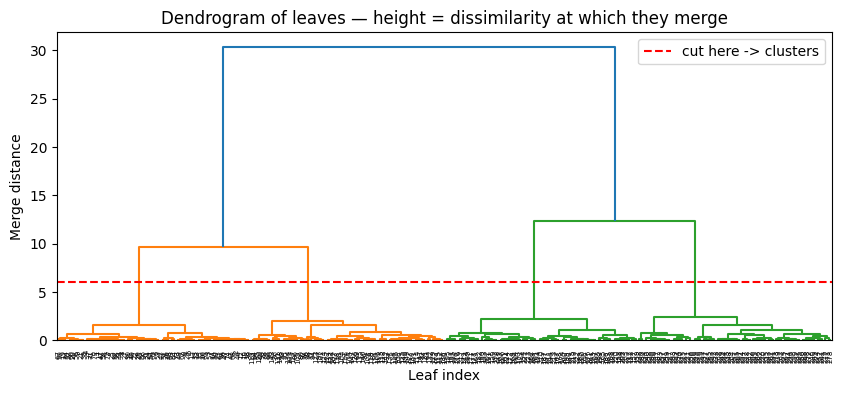

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage  # tools for hierarchical clustering + drawing its tree

sample = X_scaled[:300]                       # take the first 300 leaves to build the tree on
Z = linkage(sample, method="ward")           # build the merge history; "ward" merges groups so clusters stay tight

plt.figure(figsize=(10, 4))                   # start a wide, short figure (good shape for a tree)
dendrogram(Z)                                 # draw the dendrogram (tree) from the merge history Z
plt.title("Dendrogram of leaves — height = dissimilarity at which they merge")  # title: taller merges = more different
plt.xlabel("Leaf index"); plt.ylabel("Merge distance")  # x = which leaf, y = how far apart things were when merged
plt.axhline(y=6, color="red", ls="--", label="cut here -> clusters")  # dashed line: cutting the tree here defines the clusters
plt.legend(); plt.show()                       # show the legend, then render the tree

**Hierarchical clustering** — as an alternative to k-means. Instead of picking k up front, it starts with every leaf on its own and repeatedly merges the two closest groups, one step at a time, until everything is joined into one big group. The linkage function records that whole merge history in Z, and the dendrogram draws it as a tree.

**How to read the tree**.  The y-axis (merge distance) is the key. Each place two branches join, the height of that join tells you how different those two groups were when they merged — low join = very similar leaves, high join = quite different groups being forced together. Short joins near the bottom are the tightest, most natural groupings.

**The red line is how you get clusters** A dendrogram by itself doesn't give you a fixed number of clusters — you decide by cutting it at a chosen height. Count the vertical lines the cut crosses, and that's your number of clusters. Cut low → many small clusters; cut high → few big clusters. So this is the hierarchical answer to "how many groups?" — you can see the whole hierarchy and pick where to slice, rather than committing to k in advance (nice contrast with the elbow/silhouette approach from before).

## Hierarchical (Agglomerative) clustering

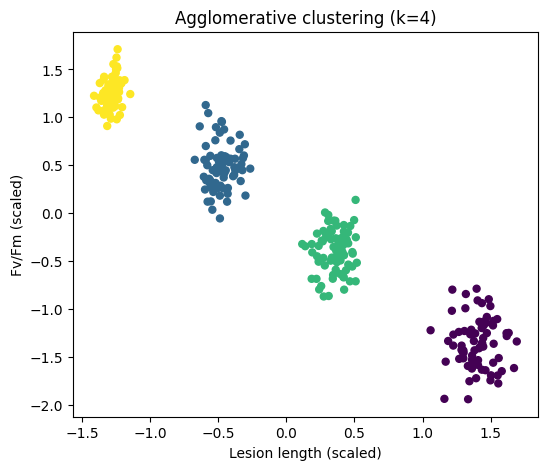

Silhouette: 0.759


In [20]:
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")  # set up hierarchical clustering to cut the tree into 4 groups; "ward" keeps clusters tight
labels_agg = agg.fit_predict(X_scaled)           # run it on the scaled data; return each leaf's cluster (0..3)

plt.figure(figsize=(6, 5))                        # start a new figure, 6 x 5 inches
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agg, cmap="viridis", s=25)  # plot leaves, colored by their hierarchical cluster
plt.title("Agglomerative clustering (k=4)")       # title naming the method and number of clusters
plt.xlabel("Lesion length (scaled)"); plt.ylabel("Fv/Fm (scaled)")  # label both axes (scaled units, not raw mm)
plt.show()                                        # render the figure

print("Silhouette:", round(silhouette_score(X_scaled, labels_agg), 3))  # score how well-separated these clusters are (higher = better)

**### You should consider using Hierarchical clustering instead of K-Means in several situations:**



* When you don't know the optimal
number of clusters (k) beforehand: Hierarchical clustering builds a complete hierarchy (a dendrogram) that allows you to determine the number of clusters after the clustering process by cutting the tree at different levels. K-Means, on the other hand, requires you to specify k in advance.
* When a tree-like structure (dendrogram) is important for understanding relationships: If you want to visualize the nested relationships between data points and clusters, similar to a phylogenetic tree, Hierarchical clustering is ideal. This is particularly useful in fields like biology (as mentioned in the notebook for plant scientists).
* For small to medium-sized datasets: Hierarchical clustering can be computationally more expensive and memory-intensive (O(n^3) for time, O(n^2) for memory) than K-Means (O(nkdi) where n is data points, k is clusters, d is dimensions, i is iterations). So, for very large datasets, K-Means is generally preferred for its speed.
* When clusters are not necessarily spherical or equal-sized: While K-Means assumes spherical, equally-sized clusters, Hierarchical clustering can be more flexible and discover clusters of various shapes, depending on the linkage method used.
* When you need deterministic results: Hierarchical clustering is deterministic (given the same parameters, it will always produce the same result), whereas K-Means can be sensitive to the initial random placement of centroids, requiring multiple runs (n_init) to find a good solution.

## 6 · DBSCAN — density-based, finds shapes and outliers

K-Means insists on round groups and forces **every** sample into a cluster. Biology is messier.
**DBSCAN** sees a cluster as a **dense region** of points; samples in sparse regions are labeled
**noise / outliers** (cluster `-1`) — perfect for **quality control** and **novel-strain hunting**.

Two knobs:
- **`eps`** — how close counts as a "neighbor" (the radius).
- **`min_samples`** — how many neighbors a point needs to sit in a dense core.

| | |
|---|---|
| **✅ Advantages** | Finds clusters of **any shape**; you don't specify the number of clusters; automatically labels **outliers/noise** (great for QC and novel-strain detection); robust to weird geometry. |
| **⚠️ Limitations** | Results hinge on `eps` (hard to tune); struggles when clusters have very different densities; degrades in very high dimensions where "distance" loses meaning. |
| **🎯 Best applied when** | Noisy, irregular data where you care about outliers — e.g. spotting an isolate that fits **no** known pathotype (possible new strain), cleaning bad measurements, or clusters that form curved bands rather than blobs. |

### A plant-health scenario where K-Means fails
Lets say that in a **field trial**, the disease spreads outward from a few infection foci, so the **infected
corn plants** trace **curved, interlocking fronts** across the plot rather than round patches. If
we map each infected plant by its **position in the field** (two spatial coordinates), those
fronts are exactly the non-round shape K-Means gets wrong — and DBSCAN gets right. We mimic two
such infection fronts below.

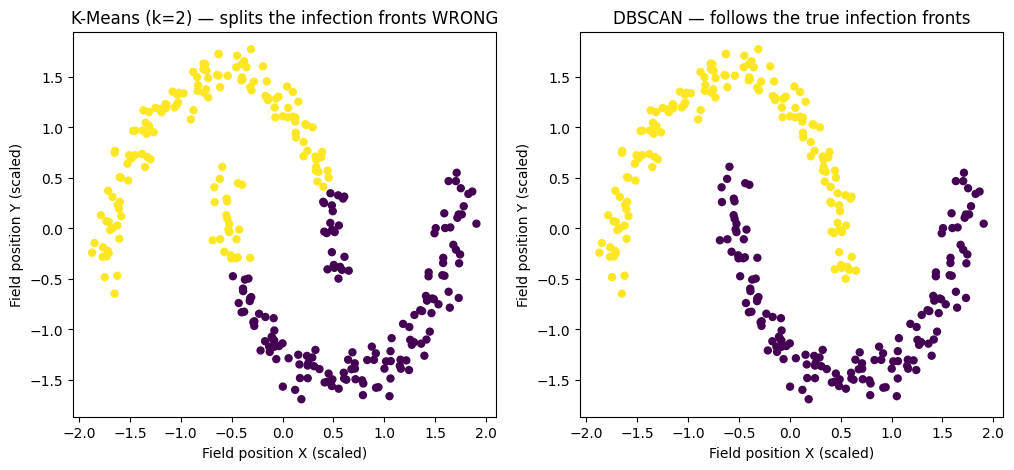

DBSCAN found clusters: {np.int64(0), np.int64(1)}   (-1 = noise/outliers)


In [21]:
X_bands, _ = make_moons(n_samples=300, noise=0.06, random_state=42)   # make 300 points in two interleaving crescent (moon) shapes; small noise; reproducible
X_bands = StandardScaler().fit_transform(X_bands)                     # scale x,y (here they're plant positions in the field)

km_bands  = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_bands)  # cluster with k-means into 2 groups
db_bands  = DBSCAN(eps=0.3, min_samples=5).fit_predict(X_bands)       # cluster with DBSCAN: groups points that are densely packed together

fig, ax = plt.subplots(1, 2, figsize=(12, 5))    # two side-by-side plots to compare the methods
ax[0].scatter(X_bands[:, 0], X_bands[:, 1], c=km_bands, cmap="viridis", s=25)  # LEFT: points colored by k-means clusters
ax[0].set_title("K-Means (k=2) — splits the infection fronts WRONG")           # k-means cuts a straight line and gets it wrong
ax[1].scatter(X_bands[:, 0], X_bands[:, 1], c=db_bands, cmap="viridis", s=25)  # RIGHT: points colored by DBSCAN clusters
ax[1].set_title("DBSCAN — follows the true infection fronts")                  # DBSCAN traces the curved shapes correctly
for a in ax: a.set_xlabel("Field position X (scaled)"); a.set_ylabel("Field position Y (scaled)")  # label axes on both plots
plt.show()                                        # render both plots

print("DBSCAN found clusters:", set(db_bands), "  (-1 = noise/outliers)")  # list DBSCAN's cluster labels; -1 means "outlier, not in any cluster"

**Why k-means fails**: it groups points around centers, so it only makes round, straight-edged blobs. You can't split two curved crescents with a straight cut, so it slices across both and gets it wrong.

**Why DBSCAN works**: it groups by density — it follows wherever points are packed closely together, so a cluster can be any shape. That lets it trace each curved front. Its settings: eps=0.3 = how close counts as neighboring, min_samples=5 = how many neighbors make a dense region.

The −1 label: DBSCAN doesn't force every point into a cluster. Lonely points get labeled −1 = outlier — something k-means never does.

Takeaway: no single best algorithm. K-means suits compact blobs; DBSCAN suits odd shapes and can flag outliers. Plot your data first.

## 7 · Seeing high-dimensional data with PCA

So far we used 2 features so we could plot directly. Real plant-health datasets have **many**
features — lesion length, % diseased area, SPAD, hyperspectral index, Fv/Fm, dozens of image or
gene-expression values. You can't plot 30 dimensions.

**PCA (Principal Component Analysis)** compresses many features into a few "principal
components" that retain as much variation as possible — usually we keep 2 for a scatter plot.
PCA is itself an unsupervised method (dimensionality reduction). Standard workflow:
**scale → cluster → PCA to 2-D for the picture.** We use it in the case study next.

| | |
|---|---|
| **✅ Advantages** | Turns many features into a 2-D picture you can actually read; removes redundancy between correlated measurements; fast; can speed up and de-noise clustering. |
| **⚠️ Limitations** | Components are **combinations** of features, so axes lose direct biological meaning; only captures **linear** structure (t-SNE/UMAP handle curved structure better for visualization); can hide small clusters. |
| **🎯 Best applied when** | You have **many** measurements (morphology panels, image features, gene-expression) and need to visualize or compress them before/after clustering. |

## 9 · Case study — profiling strains with five instruments

Now the realistic, multi-feature version. We phenotyped **240 inoculated corn leaves** from a
panel of *C. nebraskensis* strains, this time with **five** measurements spanning the modern
plant-health toolkit:

| Feature | Instrument / method | What it captures |
|---------|---------------------|------------------|
| `lesion_length_mm`   | ruler / clip assay              | visible symptom severity |
| `diseased_area_pct`  | digital image analysis (ImageJ) | % of leaf area diseased |
| `spad_chlorophyll`   | SPAD chlorophyll meter          | chlorophyll content (drops with infection) |
| `hyperspectral_di`   | hyperspectral imaging           | disease index; catches pre-symptomatic breakdown |
| `fv_fm`              | chlorophyll fluorescence        | PSII quantum yield (photosynthetic function) |

The leaves truly come from three virulence groups — **Weak**, **Moderate**, and **High** — but
imagine they arrived **unlabeled**. We'll cluster on the five measurements alone, then, because we
*do* know the true group here, **check whether the clusters match reality** — the honest way to
build trust in a method before using it on data that has no labels.

In [22]:
# --- Build the strain-phenotyping dataset (synthetic but biologically plausible) ---
rng = np.random.default_rng(0)                   # random generator, seed 0 for reproducible data
n = 80  # inoculated leaves per virulence group  # each group will have 80 leaves

def strain(lesion, area, spad, hdi, fvfm):       # helper: make one group's leaves from its typical values
    """Draw n leaves around typical values for one virulence group."""
    return pd.DataFrame({                         # each column is one measurement, 80 values long
        "lesion_length_mm":  rng.normal(lesion, lesion*0.18 + 2, n).clip(0),   # lesion length; spread grows with size; no negatives
        "diseased_area_pct": rng.normal(area,   6,    n).clip(0, 100),         # % of leaf diseased; kept within 0–100
        "spad_chlorophyll":  rng.normal(spad,   3,    n).clip(0),              # greenness/chlorophyll reading; no negatives
        "hyperspectral_di":  rng.normal(hdi,    0.06, n).clip(0, 1),           # disease index from imaging; kept within 0–1
        "fv_fm":             rng.normal(fvfm,   0.03, n).clip(0, 0.85),        # PSII efficiency; capped at 0.85 (real ceiling)
    })

#                   lesion area spad  hdi  fvfm
weak     = strain(    30,  12,  50, 0.15, 0.80)   # weak strain: short lesions, green, healthy PSII
moderate = strain(    95,  38,  37, 0.45, 0.68)   # moderate strain: mid-range on every measure
high     = strain(   165,  72,  25, 0.75, 0.52)   # high strain: long lesions, chlorotic, PSII damaged

survey = pd.concat([weak, moderate, high], ignore_index=True)  # stack the 3 groups into one table (240 leaves); renumber rows 0..239
true_group  = np.array([0]*n + [1]*n + [2]*n)            # answer key: first 80 = group 0, next 80 = 1, last 80 = 2 (HELD OUT = not given to the algorithm)
group_names = np.array(["Weak", "Moderate", "High"])    # human-readable names for those 3 groups
Xs_raw = survey.to_numpy()                        # the measurements as a plain NumPy array (for the clustering steps)
print("Dataset shape:", survey.shape)             # report size: (240, 5) -> 240 leaves, 5 measurements each
survey.describe().round(1)                         # quick summary stats (mean, min, max, etc.) per column

Dataset shape: (240, 5)


,lesion_length_mm,diseased_area_pct,spad_chlorophyll,hyperspectral_di,fv_fm
count,240.0,240.0,240.0,240.0,240.0
mean,97.4,40.2,37.0,0.5,0.7
std,58.1,24.9,10.8,0.3,0.1
min,12.8,0.0,17.0,0.0,0.4
25%,35.6,15.8,26.1,0.2,0.5
50%,94.2,38.6,36.9,0.5,0.7
75%,149.8,66.9,47.7,0.7,0.8
max,235.6,86.9,59.2,0.9,0.8


In [28]:
# 1) SCALE the five features (essential — mm, %, SPAD units, an index, and a ratio are all different scales)
Xs = StandardScaler().fit_transform(Xs_raw)

# 2) CLUSTER with K-Means, asking for 3 groups (we do NOT pass the true labels!)
survey_km = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(Xs)

# 3) COMPRESS 5 features -> 2 with PCA, just so we can plot
Xs_2d = PCA(n_components=2).fit_transform(Xs)

### PCA without cluster labels

To better understand PCA's role, here is the same PCA plot without any cluster labels applied. The points are shown in a single color, reflecting only their position in the reduced 2-dimensional space, independent of any clustering results. As you can see, without colors, it's much harder to discern distinct groups.

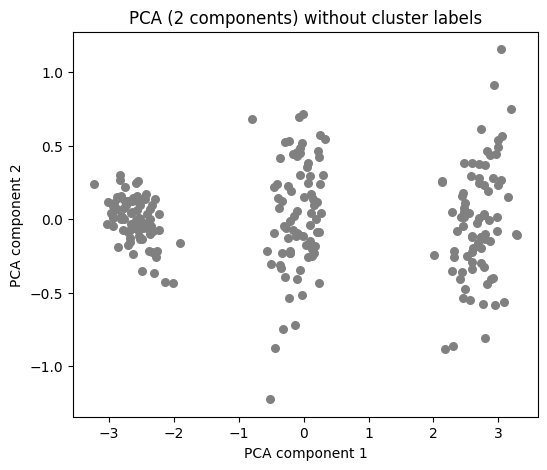

In [29]:
plt.figure(figsize=(6, 5))
plt.scatter(Xs_2d[:,0], Xs_2d[:,1], s=30, color='gray') # Plotting without 'c' argument for coloring
plt.title("PCA (2 components) without cluster labels")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

PC1:  94.3% of variability
PC2:   2.1% of variability
PC3:   1.5% of variability
PC4:   1.1% of variability
PC5:   1.0% of variability
PC1 + PC2 together: 96.4%


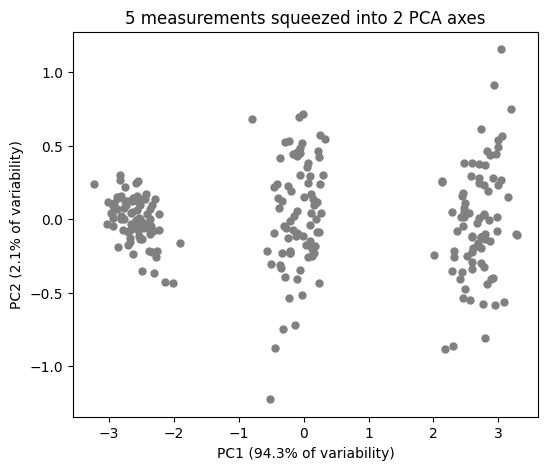

In [31]:
from sklearn.decomposition import PCA          # PCA: squeezes many measurements down to a few summary axes

Xs_scaled = StandardScaler().fit_transform(Xs_raw)  # scale first: all 5 measurements on equal footing (PCA uses variance, so scale matters)

pca = PCA(n_components=5)                        # set up PCA, asking for all 5 components (one per original measurement)
scores = pca.fit_transform(Xs_scaled)           # fit PCA and project every leaf onto the new component axes

var_pct = pca.explained_variance_ratio_ * 100   # % of the data's total variability each component captures
for i, v in enumerate(var_pct, start=1):        # loop over the components, numbering them PC1, PC2, ...
    print(f"PC{i}: {v:5.1f}% of variability")   # print each component's share of the variability
print(f"PC1 + PC2 together: {var_pct[:2].sum():.1f}%")  # how much the first TWO axes capture (what we'll plot in 2D)

plt.figure(figsize=(6, 5))                       # new figure for the 2D PCA view
plt.scatter(scores[:, 0], scores[:, 1], s=25, color="gray")  # plot leaves on PC1 vs PC2, all one color (no group labels)
plt.title("5 measurements squeezed into 2 PCA axes")  # title: 5D data shown in 2D
plt.xlabel(f"PC1 ({var_pct[0]:.1f}% of variability)")  # x-axis = PC1, with its % of variability
plt.ylabel(f"PC2 ({var_pct[1]:.1f}% of variability)")  # y-axis = PC2, with its % of variability
plt.show()                                       # render the plot

**axis : explained_variance_ratio_** tells you what share of the data's total spread each component captures. The five values add up to 100%, and putting PC1 and PC2's percentages on the axis labels shows how much of the full picture the 2D plot is actually showing.

### PCA plot colored by K-Means discovered clusters

Now that PCA has given us a 2D view of the data, we can use the labels from K-Means to color these points. Each color represents a group that K-Means found. Remember, K-Means simply assigns numbers (like 0, 1, 2) to its clusters. These numbers are arbitrary, so the colors chosen for them by the plot are also arbitrary. This plot helps us see if the clusters K-Means found are visually distinct in this simplified 2D space.

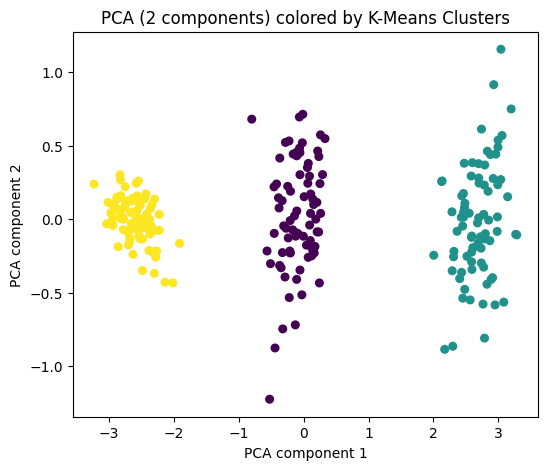

In [32]:
plt.figure(figsize=(6, 5))                       # start a new figure, 6 x 5 inches
plt.scatter(Xs_2d[:,0], Xs_2d[:,1], c=survey_km, cmap="viridis", s=30)  # plot leaves on the 2 PCA axes, colored by their k-means cluster
plt.title("PCA (2 components) colored by K-Means Clusters")  # title: PCA gives the layout, k-means gives the colors
plt.xlabel("PCA component 1")                    # x-axis = first PCA component (the direction of most spread)
plt.ylabel("PCA component 2")                    # y-axis = second PCA component (next most spread)
plt.show()                                       # render the figure

### PCA plot colored by the TRUE virulence groups

For comparison, here is the exact same PCA plot, but this time we'll color the points based on their *actual*, known virulence groups (`true_group`). This is what the groups *really* look like. By comparing this to the K-Means colored plot, we can see how well K-Means did at finding these true groups, even if the specific colors don't match up perfectly (because K-Means labels are arbitrary).

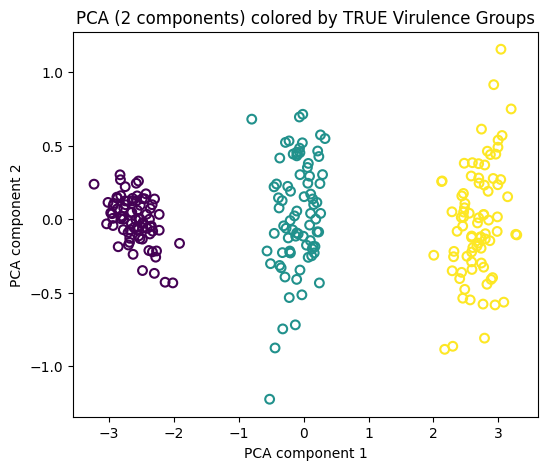

In [37]:
import matplotlib.cm as cm                        # to turn group numbers into colors ourselves
colors = cm.viridis(true_group / true_group.max())  # map each group (0,1,2) to a viridis color

plt.figure(figsize=(6, 5))                        # new figure, 6 x 5 inches
plt.scatter(Xs_2d[:,0], Xs_2d[:,1],               # plot the leaves
            facecolors="none",                    # empty centers
            edgecolors=colors,                    # colored OUTLINE per leaf (this is the key change)
            s=40, linewidths=1.5)                 # dot size and ring thickness
plt.title("PCA (2 components) colored by TRUE Virulence Groups")  # the real answer
plt.xlabel("PCA component 1")                     # x-axis = first PCA component
plt.ylabel("PCA component 2")                     # y-axis = second PCA component
plt.show()                                        # render the figure                                     # render the figure

### PCA plot with K-Means labels re-mapped to match True Group colors

To visually confirm that K-Means successfully identified the same groupings as the true virulence groups, we can re-map the arbitrary integer labels assigned by K-Means (`survey_km`) to align with the labels of the `true_group`. This plot uses the K-Means clusters, but with colors assigned to visually match the 'true' labels. This should look very similar, if not identical, to the plot colored by `true_group`.

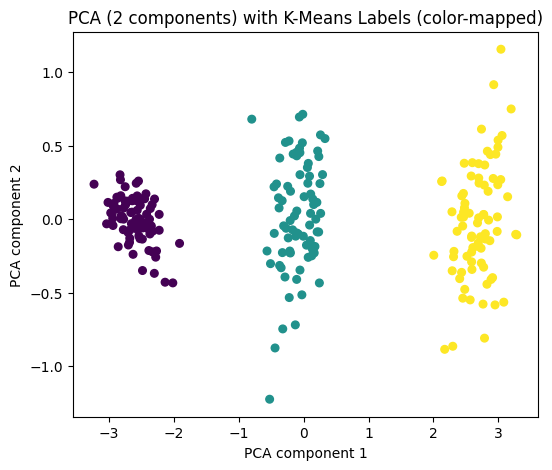

In [38]:
# Create a re-mapping of K-Means labels to align with true_group colors
# Based on the crosstab in cell Yu9qJ0V1xoJo:
# K-Means cluster 0 corresponds to true_group 1 ('Moderate')
# K-Means cluster 1 corresponds to true_group 2 ('High')
# K-Means cluster 2 corresponds to true_group 0 ('Weak')

survey_km_remapped = np.zeros_like(survey_km)     # make an all-zeros array the same size to hold the renumbered labels
survey_km_remapped[survey_km == 0] = 1 # every leaf k-means called 0 (Moderate) -> relabel as 1 to match true 'Moderate'
survey_km_remapped[survey_km == 1] = 2 # every leaf k-means called 1 (High)     -> relabel as 2 to match true 'High'
survey_km_remapped[survey_km == 2] = 0 # every leaf k-means called 2 (Weak)     -> relabel as 0 to match true 'Weak'

plt.figure(figsize=(6, 5))                        # start a new figure, 6 x 5 inches
plt.scatter(Xs_2d[:,0], Xs_2d[:,1], c=survey_km_remapped, cmap="viridis", s=30)  # same PCA plot, now colored by the RENUMBERED k-means labels
plt.title("PCA (2 components) with K-Means Labels (color-mapped)")  # title: k-means result, recolored to line up with the truth
plt.xlabel("PCA component 1")                     # x-axis = first PCA component
plt.ylabel("PCA component 2")                     # y-axis = second PCA component
plt.show()                                        # render the figure

The two pictures line up closely — K-Means recovered the three virulence groups from the five
instrument readouts alone, **without ever seeing a label**. Weak strains sit far from the
aggressive ones, with Moderate bridging them.

## 10 · Which algorithm should I use?

| Algorithm | Pick *k* first? | Cluster shape | Finds outliers? | Best for (plant-health) |
|-----------|:---:|-----------|:---:|----------|
| **K-Means** | Yes | Round, similar size | No | Fast first pass on isolates/leaves; big datasets |
| **Hierarchical** | No* | Flexible | No | Few–medium samples; want a phylogeny-like tree |
| **DBSCAN** | No | Any shape | **Yes** | Field-map shapes, noisy data, novel-strain / QC outliers |
| **GMM** | Yes | Elliptical | No | Mixed-symptom leaves; want soft probabilities |

*Hierarchical builds the whole tree; you choose the number of clusters by cutting it afterward.

**Practical workflow for your projects:**
1. **Always scale** your measurements first.
2. Start with **K-Means** + elbow/silhouette to get a feel for how many groups exist.
3. If groups look non-round or you need outliers, try **DBSCAN**.
4. If you want a tree or have few samples, use **Hierarchical**.
5. If memberships are fuzzy/overlapping, use **GMM**.
6. Use **PCA** to visualize, describe each cluster's **feature profile**, and sanity-check
   against **domain knowledge**.
7. If your data mixes **numbers and categories**, don't use K-Means

---

## 12 · ✏️ Exercises

Try these yourself; solutions are in the last section.

**Ex 1.** Re-run K-Means on the **clip-assay** data `X_scaled` (lesion length × Fv/Fm) with **k = 3**
instead of 4. Plot the
result and print the silhouette score. Is it higher or lower than k = 4?

**Ex 2.** Change DBSCAN's `eps` on the field-map data `X_bands` (infection fronts) to **0.15**, then **0.6**. What
happens to the number of clusters and the amount of noise (`-1`)?

In [ ]:
# Ex 1 — your code here


In [ ]:
# Ex 2 — your code here


## 13 · 📌 Clustering cheat-sheet

```python
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 1. ALWAYS scale first
Xs = StandardScaler().fit_transform(X)

# 2. Cluster (labels = which cluster each sample got)
labels = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(Xs)
labels = AgglomerativeClustering(n_clusters=4).fit_predict(Xs)
labels = DBSCAN(eps=0.3, min_samples=5).fit_predict(Xs)   # -1 = noise/outliers
labels = GaussianMixture(n_components=4, random_state=0).fit_predict(Xs)

# 3. Evaluate WITHOUT labels (higher = better, range -1..1)
silhouette_score(Xs, labels)

# 4. Evaluate WITH known labels (1 = perfect, 0 = random)
adjusted_rand_score(true_labels, labels)

# 5. Visualize many features in 2-D
X2 = PCA(n_components=2).fit_transform(Xs)
plt.scatter(X2[:,0], X2[:,1], c=labels)

# 6. Describe a cluster = average feature profile per cluster
df.groupby(labels).mean()

# NO in this lectures : DO not use Kmeans if MIXED numeric + categorical data. You have to "trasform your categorical data"
#   a) one-hot encode categoricals, then any numeric method
#   b) Gower distance -> AgglomerativeClustering(metric='precomputed', linkage='average')
#   c) K-Prototypes:  from kmodes.kprototypes import KPrototypes   # pip install kmodes
```

**Remember:** clustering has no single "right answer." Different algorithms and settings give
different groupings — your job is to find the one that is *stable* and *biologically sensible*.

---

## 14 · ✅ Solutions

Try first, then run these to check.

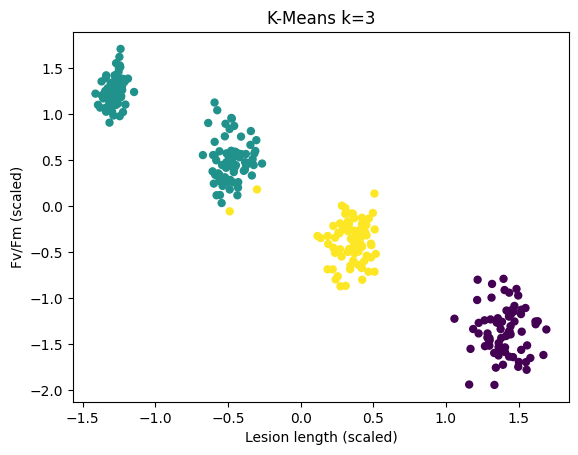

Silhouette k=3: 0.661
Silhouette k=4: 0.759
-> k=4 scores higher because the leaves truly form 4 virulence groups.


In [ ]:
# --- Ex 1: K-Means with k=3 on clip-assay data (lesion x Fv/Fm) ---
km3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=km3, cmap="viridis", s=25)
plt.title("K-Means k=3"); plt.xlabel("Lesion length (scaled)"); plt.ylabel("Fv/Fm (scaled)")
plt.show()
print("Silhouette k=3:", round(silhouette_score(X_scaled, km3), 3))
print("Silhouette k=4:", round(silhouette_score(X_scaled,
      KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)), 3))
print("-> k=4 scores higher because the leaves truly form 4 virulence groups.")

In [ ]:
# --- Ex 2: DBSCAN eps sensitivity on the field map (infection fronts) ---
for e in [0.15, 0.3, 0.6]:
    lab = DBSCAN(eps=e, min_samples=5).fit_predict(X_bands)
    n_clusters = len(set(lab) - {-1})
    n_noise = int((lab == -1).sum())
    print(f"eps={e}: clusters={n_clusters}, noise points={n_noise}")
print("-> small eps: almost everything becomes noise; large eps: the two fronts merge into one.")

eps=0.15: clusters=16, noise points=26
eps=0.3: clusters=2, noise points=0
eps=0.6: clusters=1, noise points=0
-> small eps: almost everything becomes noise; large eps: the two fronts merge into one.


---
## 🎉 Wrap-up

You now know the core of unsupervised clustering, in a plant-health context:

- **Scale first**, because clustering is about distance and plant data mixes many units.
- **K-Means** for a fast, round-group first pass; use the **elbow** + **silhouette** to pick *k*.
- **Hierarchical** when you want a **dendrogram** (a tree, like a phylogeny) and no fixed *k*.
- **DBSCAN** for **odd shapes and outliers** — novel-strain hunting and QC.
- **GMM** for **soft, overlapping** memberships (mixed-symptom samples).
- **PCA** to **see** clusters that live in many measurements.
- Validate with the **silhouette score**, cluster **feature profiles**, and, above all,
  **biological sense**.

**Next step:** with these tools you can group unlabeled leaf images, strain phenotypes, or
pathogen genotypes.